In [1]:
!pip install segmentation-models-pytorch albumentations opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.2 MB/s eta 0:00:0000:01


In [2]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import warnings
import time as t
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss, FocalLoss

from tqdm import tqdm

# ==================== КОНФИГУРАЦИЯ ====================
class Config:
    # Пути к данным (на Kaggle датасет монтируется в /kaggle/input/имя_датасета/)
    # Укажите фактическое имя вашего датасета
    DATA_DIR = "/kaggle/input/datasets/ilnar31"  # замените на своё
    
    # Параметры модели
    ENCODER = 'resnet50'          # resnet50 дал лучший результат
    ENCODER_WEIGHTS = 'imagenet'
    IMAGE_HEIGHT = 832
    IMAGE_WIDTH = 832
    BATCH_SIZE = 4                 # можно увеличить до 12 при 2xT4
    LEARNING_RATE = 1e-4
    NUM_EPOCHS = 150
    PATIENCE = 5                   # ранняя остановка
    
    # Дополнительные кропы верхней части тела
    USE_UPPER_BODY_CROPS = True
    CROP_RATIOS = [0.4, 0.5]        # доля верхней части от bounding box
    
    # Временное сглаживание (не используется в обучении)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
config = Config()

print(f"Устройство: {config.DEVICE}")
print(f"Доступно GPU: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")


Устройство: cuda
Доступно GPU: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
def set_seed(seed=42):
    # random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:

# ==================== ДАТАСЕТ С КРОПАМИ ПЛЕЧ ====================
def extract_upper_body_crop(image, mask, crop_ratio,flag=True):
    if flag:
        y_indices, x_indices = np.where(mask > 0)
        if len(y_indices) == 0:
            return None, None
        y_min, y_max = y_indices.min(), y_indices.max()
        x_min, x_max = x_indices.min(), x_indices.max()
        height = y_max - y_min
        crop_y_max = y_min + int(height * crop_ratio)
        crop_y_min = y_min
        crop_img = image[crop_y_min:crop_y_max, x_min:x_max]
        crop_mask = mask[crop_y_min:crop_y_max, x_min:x_max]
    else:
        y_indices, x_indices = np.where(mask > 0)
        if len(y_indices) == 0:
            return None, None
        y_min, y_max = y_indices.min(), y_indices.max()
        x_min, x_max = x_indices.min(), x_indices.max()
        height = y_max - y_min
        crop_y_max = y_max
        crop_y_min = y_max - int(height * crop_ratio)
        crop_img = image[crop_y_min:crop_y_max, x_min:x_max]
        crop_mask = mask[crop_y_min:crop_y_max, x_min:x_max]
    if crop_img.size == 0 or crop_mask.size == 0:
        return None, None
    return crop_img, crop_mask

class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, add_upper_body_crops=False):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.add_upper_body_crops = add_upper_body_crops
        
        # Собираем все оригинальные файлы
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(('.jpg','.png'))])
        self.samples = []  # список кортежей (img, mask)
        
        for img_name in self.image_files:
            img_path = os.path.join(images_dir, img_name)
            mask_path = os.path.join(masks_dir, img_name)
            image = np.array(Image.open(img_path).convert("RGB"))
            mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
            if mask.max() > 1:
                mask = mask / 255.0
            self.samples.append((image, mask))  # оригинал
            
            if self.add_upper_body_crops:
                if 'data' in img_name:
                    flag = True
                else:
                    flag = False
                    config.CROP_RATIOS = [0.6]
                for ratio in config.CROP_RATIOS:
                    crop_img, crop_mask = extract_upper_body_crop(image, mask, ratio, flag)
                    if crop_img is not None:
                        self.samples.append((crop_img, crop_mask))
        
        print(f"Всего образцов после добавления кропов: {len(self.samples)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        image, mask = self.samples[idx]
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        return image, mask.unsqueeze(0)

# ==================== АУГМЕНТАЦИИ ====================
train_transform = A.Compose([
    A.Resize(config.IMAGE_HEIGHT, config.IMAGE_WIDTH),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.Rotate(limit=15, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(config.IMAGE_HEIGHT, config.IMAGE_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ==================== ПОДГОТОВКА ДАННЫХ ====================
full_dataset = SegmentationDataset(
    images_dir=os.path.join(config.DATA_DIR, 'images-1'),
    masks_dir=os.path.join(config.DATA_DIR, 'masks1'),
    transform=None,
    add_upper_body_crops=config.USE_UPPER_BODY_CROPS
)

# Разделение (подберите размеры под ваш датасет)
total = len(full_dataset)
train_size = int(0.85 * total)
val_size = total - train_size
# test_size = total - train_size - val_size
# val_size = total - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

# Назначаем трансформы
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
# test_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
# test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                        # num_workers=2, pin_memory=True)

print(f"Обучающих образцов: {len(train_dataset)}")
print(f"Валидационных образцов: {len(val_dataset)}")
# print(f"Тестовых образцов: {len(test_dataset)}")

Всего образцов после добавления кропов: 656
Обучающих образцов: 557
Валидационных образцов: 99


Размер оригинала: (3840, 2160, 3)


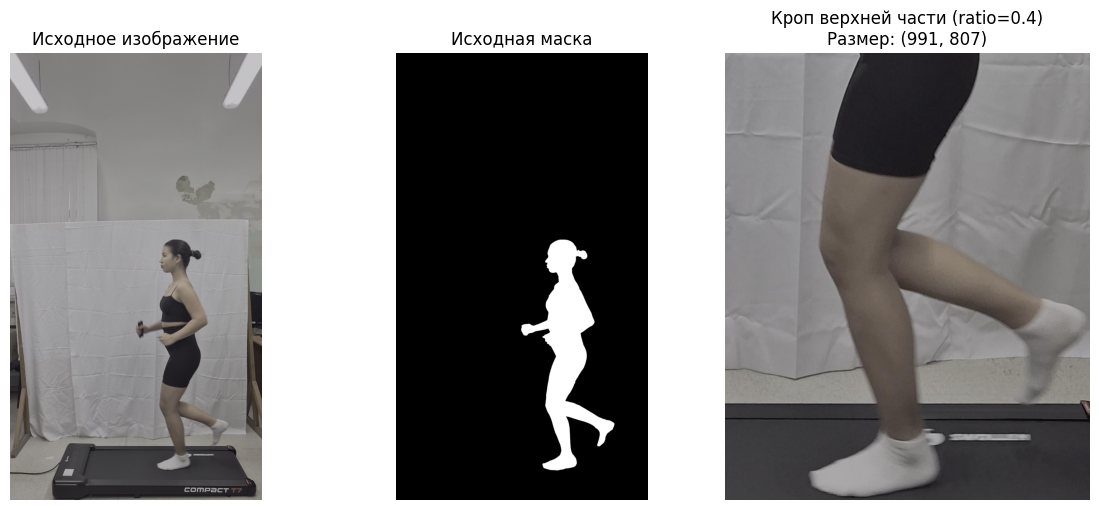

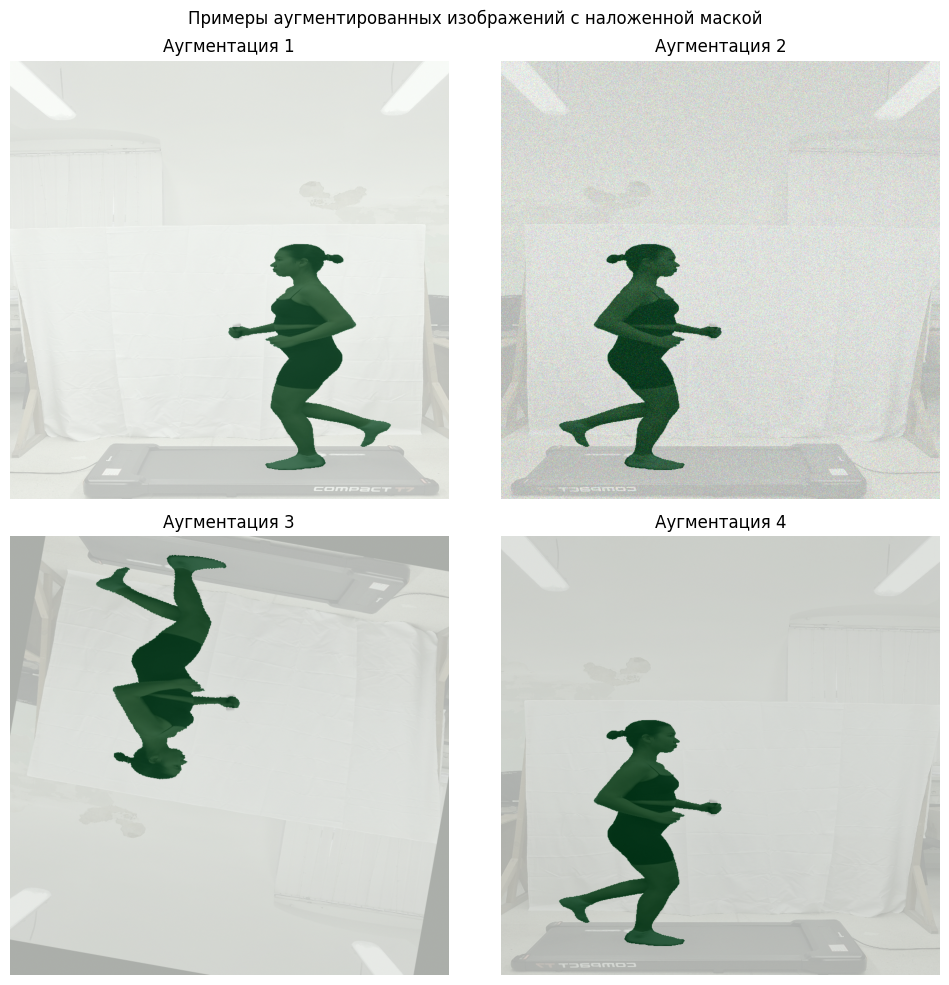

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2


def extract_upper_body_crop(image, mask, crop_ratio, flag):
    if flag:
        y_indices, x_indices = np.where(mask > 0)
        if len(y_indices) == 0:
            return None, None
        y_min, y_max = y_indices.min(), y_indices.max()
        x_min, x_max = x_indices.min(), x_indices.max()
        height = y_max - y_min
        crop_y_max = y_min + int(height * crop_ratio)
        crop_y_min = y_min
        crop_img = image[crop_y_min:crop_y_max, x_min:x_max]
        crop_mask = mask[crop_y_min:crop_y_max, x_min:x_max]
    else:
        y_indices, x_indices = np.where(mask > 0)
        if len(y_indices) == 0:
            return None, None
        y_min, y_max = y_indices.min(), y_indices.max()
        x_min, x_max = x_indices.min(), x_indices.max()
        height = y_max - y_min
        crop_y_max = y_max
        crop_y_min = y_max - int(height * crop_ratio)
        crop_img = image[crop_y_min:crop_y_max, x_min:x_max]
        crop_mask = mask[crop_y_min:crop_y_max, x_min:x_max]
    if crop_img.size == 0 or crop_mask.size == 0:
        return None, None
    return crop_img, crop_mask

# Путь к данным (замените на свой)
DATA_DIR = "/kaggle/input/datasets/ilnar31"  # Например, /kaggle/input/medical

# Выберите один файл для примера
img_name = "184.jpg"  # Замените на реальное имя файла
img_path = f"{DATA_DIR}/images-1/{img_name}"
mask_path = f"{DATA_DIR}/masks1/{img_name}"

# Загружаем оригиналы
image = np.array(Image.open(img_path).convert("RGB"))
mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
if mask.max() > 1:
    mask = mask / 255.0

print(f"Размер оригинала: {image.shape}")

# 1. Отображаем исходное изображение и маску
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Исходное изображение")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("Исходная маска")
plt.axis('off')

# 2. Получаем кроп верхней части тела (например, crop_ratio=0.4)
if 'data' in img_name:
    flag = True
else:
    flag = False
crop_img, crop_mask = extract_upper_body_crop(image, mask, crop_ratio=0.5, flag=flag)
if crop_img is not None:
    plt.subplot(1, 3, 3)
    plt.imshow(crop_img)
    plt.title(f"Кроп верхней части (ratio=0.4)\nРазмер: {crop_img.shape[:2]}")
    plt.axis('off')
else:
    print("Не удалось вырезать кроп (нет объекта на маске).")
plt.tight_layout()
plt.show()

# 3. Демонстрация аугментаций (применяем train_transform несколько раз)
# Сначала подготовим изображение и маску к аугментациям (они ожидают тип uint8 и float соответственно)
# train_transform уже включает нормализацию и ToTensorV2, поэтому для отображения нам нужно денормализовать.

# Функция денормализации
def denormalize(tensor_img, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = tensor_img.cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

# Создаём сетку 2x2 для 4 примеров аугментаций
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for i in range(4):
    # Применяем train_transform к оригинальному изображению и маске
    augmented = train_transform(image=image, mask=mask)
    aug_img = augmented['image']          # тензор 3xHxW, нормализованный
    aug_mask = augmented['mask']          # тензор 1xHxW
    
    # Денормализуем изображение для показа
    aug_img_np = denormalize(aug_img)
    
    # Маску можно оставить как есть (она уже в [0,1])
    aug_mask_np = aug_mask.squeeze().cpu().numpy()
    
    # Отображаем изображение и маску рядом (или можно совместить)
    axes[i].imshow(aug_img_np)
    axes[i].imshow(aug_mask_np, alpha=0.7, cmap='Greens')  # накладываем маску полупрозрачно
    axes[i].set_title(f"Аугментация {i+1}")
    axes[i].axis('off')

plt.suptitle("Примеры аугментированных изображений с наложенной маской")
plt.tight_layout()
plt.show()

In [6]:

# ==================== МОДЕЛЬ И ФУНКЦИЯ ПОТЕРЬ ====================
model = smp.Unet(
    encoder_name=config.ENCODER,
    encoder_weights=config.ENCODER_WEIGHTS,
    in_channels=3,
    classes=1,
    activation='sigmoid'
)

# Используем DataParallel, если несколько GPU
if torch.cuda.device_count() > 1:
    print(f"Используем {torch.cuda.device_count()} GPU")
    model = nn.DataParallel(model)
model = model.to(config.DEVICE)

def smoothed_bce_loss(pred, target, smoothing=0.1):
    target = target * (1 - smoothing) + 0.5 * smoothing
    return nn.BCELoss()(pred, target)

criterion_dice = DiceLoss(mode='binary')
criterion_focal = FocalLoss(mode='binary')
# BCE = nn.BCELoss()

def Dice_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return dice.cpu().numpy() if dice else 0

def combined_loss(pred, target):
    
    return 0.6*criterion_dice(pred, target) + 0.4*smoothed_bce_loss(pred, target)  # можно регулировать веса

optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ==================== ОБУЧЕНИЕ ====================
def train_epoch(model, loader, optimizer, device):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(loader, desc="Training", leave=False)
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})
    return epoch_loss / len(loader)

def validate_epoch(model, loader, device, task='val'):
    model.eval()
    epoch_loss = 0.0
    iou_scores, dice_scores = [], []
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = combined_loss(outputs, masks)
            epoch_loss += loss.item()
            preds = (outputs > 0.5).float()
            intersection = (preds * masks).sum((1,2,3))
            union = preds.sum((1,2,3)) + masks.sum((1,2,3)) - intersection
            iou = (intersection + 1e-6) / (union + 1e-6)
            iou_scores.extend(iou.cpu().numpy())
            if task == 'test':
                scores = Dice_score(preds, masks)
                # print(scores)
                # print(iou_scores)
                dice_scores.append(scores)
            
    avg_iou = np.mean(iou_scores) if iou_scores else 0
    avg_dice = np.mean(dice_scores) if iou_scores else 0
    return epoch_loss / len(loader), avg_iou, avg_dice

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Используем 2 GPU


In [7]:

# ==================== ОБУЧЕНИЕ ====================
def train_epoch(model, loader, optimizer, device):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(loader, desc="Training", leave=False)
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})
    return epoch_loss / len(loader)

def validate_epoch(model, loader, device, task='val'):
    model.eval()
    epoch_loss = 0.0
    iou_scores, dice_scores = [], []
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = combined_loss(outputs, masks)
            epoch_loss += loss.item()
            preds = (outputs > 0.5).float()
            intersection = (preds * masks).sum((1,2,3))
            union = preds.sum((1,2,3)) + masks.sum((1,2,3)) - intersection
            iou = (intersection + 1e-6) / (union + 1e-6)
            iou_scores.extend(iou.cpu().numpy())
            if task == 'test':
                scores = Dice_score(preds, masks)
                # print(scores)
                # print(iou_scores)
                dice_scores.append(scores)
            
    avg_iou = np.mean(iou_scores) if iou_scores else 0
    avg_dice = np.mean(dice_scores) if iou_scores else 0
    return epoch_loss / len(loader), avg_iou, avg_dice

In [8]:
# Для логирования

    
train_losses, val_losses, val_ious, ep_time = [], [], [], []
best_iou = 0.0
epochs_no_improve = 0
best_model_path = "/kaggle/working/best_model_u.pth"

print("\nНачинаем обучение...")
for epoch in range(config.NUM_EPOCHS):
    start = t.time()
    print(f"\nЭпоха {epoch+1}/{config.NUM_EPOCHS}")
    train_loss = train_epoch(model, train_loader, optimizer, config.DEVICE)
    val_loss, val_iou, val_dice = validate_epoch(model, val_loader, config.DEVICE)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ious.append(val_iou)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")
    
    scheduler.step(val_loss)
    ep_time.append(t.time() - start)
    # Сохранение лучшей модели
    if val_iou - best_iou > 0.001:
        best_iou = val_iou
        # Если модель в DataParallel, сохраняем module.state_dict()
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), best_model_path)
        else:
            torch.save(model.state_dict(), best_model_path)
        print(f"  -> Лучшая модель с IoU: {best_iou:.4f}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"  -> IoU не улучшился {epochs_no_improve}/{config.PATIENCE}")
    
    if epochs_no_improve >= config.PATIENCE:
        print(f"Ранняя остановка на эпохе {epoch+1}")
        break
    
# Загрузка лучшей модели
if isinstance(model, nn.DataParallel):
    model.module.load_state_dict(torch.load(best_model_path))
else:
    model.load_state_dict(torch.load(best_model_path))


Начинаем обучение...

Эпоха 1/150


Train Loss: 0.4773 | Val Loss: 0.4191 | Val IoU: 0.9411
  -> Лучшая модель с IoU: 0.9411

Эпоха 2/150


Train Loss: 0.4124 | Val Loss: 0.3995 | Val IoU: 0.9446
  -> Лучшая модель с IoU: 0.9446

Эпоха 3/150


Train Loss: 0.3981 | Val Loss: 0.3877 | Val IoU: 0.9744
  -> Лучшая модель с IoU: 0.9744

Эпоха 4/150


Train Loss: 0.3960 | Val Loss: 0.4811 | Val IoU: 0.7799
  -> IoU не улучшился 1/5

Эпоха 5/150


...

Train Loss: 0.3838 | Val Loss: 0.3834 | Val IoU: 0.9809
  -> IoU не улучшился 1/5

Эпоха 11/150


Train Loss: 0.3850 | Val Loss: 0.3863 | Val IoU: 0.9708
  -> IoU не улучшился 2/5

Эпоха 12/150


Train Loss: 0.3875 | Val Loss: 0.3863 | Val IoU: 0.9683
  -> IoU не улучшился 3/5

Эпоха 13/150


Train Loss: 0.3852 | Val Loss: 0.3841 | Val IoU: 0.9780
  -> IoU не улучшился 4/5

Эпоха 14/150


Train Loss: 0.3830 | Val Loss: 0.3847 | Val IoU: 0.9755
  -> IoU не улучшился 5/5
Ранняя остановка на эпохе 14


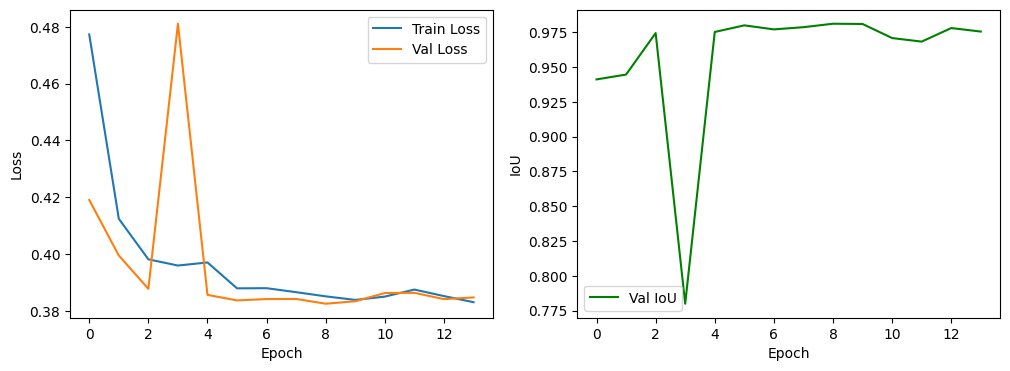

In [14]:
# ==================== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ====================
# Графики
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_ious, label='Val IoU', color='green')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()
plt.savefig('/kaggle/working/tr_curves_unet.png')
plt.show()

In [10]:
# # ==================== 6. ТЕСТИРОВАНИЕ И ВИЗУАЛИЗАЦИЯ ====================
# def visualize_results(model, loader, device, num_samples=4):
#     model.eval()
#     fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    
#     with torch.no_grad():
#         for i, (images, masks) in enumerate(loader):
#             if i >= num_samples:
#                 break
            
#             images = images.to(device)
#             masks = masks.to(device)
            
#             outputs = model(images)
#             preds = (outputs > 0.5).float()
            
#             # Конвертируем тензоры в numpy для визуализации
#             img_np = images[0].cpu().permute(1, 2, 0).numpy()
#             # Денормализация
#             mean = np.array([0.485, 0.456, 0.406])
#             std = np.array([0.229, 0.224, 0.225])
#             img_np = std * img_np + mean
#             img_np = np.clip(img_np, 0, 1)
            
#             mask_np = masks[0, 0].cpu().numpy()
#             pred_np = preds[0, 0].cpu().numpy()
            
#             # Визуализация
#             axes[i, 0].imshow(img_np)
#             axes[i, 0].set_title("Исходное изображение")
#             axes[i, 0].axis('off')
            
#             axes[i, 1].imshow(mask_np, cmap='gray')
#             axes[i, 1].set_title("Истинная маска")
#             axes[i, 1].axis('off')
            
#             axes[i, 2].imshow(pred_np, cmap='Greens')
#             axes[i, 2].set_title(f"Предсказание (IoU: {calculate_iou(pred_np, mask_np):.3f})\
#                                     (Dice: {Dice_score(preds, masks):.3f})")
#             axes[i, 2].axis('off')
    
#     plt.tight_layout()
#     plt.show()
    

# def calculate_iou(pred, target, threshold=0.5):
#     pred_bin = pred > threshold
#     target_bin = target > threshold
    
#     intersection = np.logical_and(pred_bin, target_bin).sum()
#     union = np.logical_or(pred_bin, target_bin).sum()
    
#     return intersection / union if union > 0 else 0


# # Тестирование на тестовом наборе
# print("\nТестирование на тестовом наборе...")
# test_loss, test_iou, dice_scores = validate_epoch(model, test_loader, config.DEVICE, task='test')
# print(f"Результат на тестовом наборе: Loss = {test_loss:.4f}, IoU = {test_iou:.4f}, Dice = {dice_scores:.4f}")

# # Визуализация нескольких примеров
# print("\nВизуализация результатов...")
# visualize_results(model, test_loader, config.DEVICE, num_samples=min(3, len(test_dataset)))

In [16]:
# CSV лог
df = pd.DataFrame({
    'epoch': list(range(1, len(train_losses)+1)),
    'train_loss': train_losses,
    'val_loss': val_losses,
    'val_iou': val_ious,
    'ep_time': ep_time
})
df.to_csv('/kaggle/working/log_unet.csv', index=False)

In [15]:
# Сохраняем полную модель для инференса
checkpoint = {
    'model_state_dict': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
    'encoder': config.ENCODER,
    'image_size': (config.IMAGE_HEIGHT, config.IMAGE_WIDTH),
    'classes': 1,
}
torch.save(checkpoint, '/kaggle/working/U_net.pth')

print("\nОбучение завершено. Файлы сохранены в /kaggle/working/")
print(f"Лучший IoU: {best_iou:.4f}")


Обучение завершено. Файлы сохранены в /kaggle/working/
Лучший IoU: 0.9811


In [13]:
# import matplotlib.pyplot as plt

# # Предположим, у вас есть test_loader
# for batch_idx, (images, masks) in enumerate(test_loader):
#     # images: тензор размером (batch_size, 3, H, W)
#     # masks: тензор размером (batch_size, 1, H, W)
    
#     for i in range(images.size(0)):
#         img = images[i].cpu().permute(1, 2, 0).numpy()  # (H, W, 3)
#         mask = masks[i, 0].cpu().numpy()               # (H, W)
        
#         # Денормализация, если применяли нормализацию
#         mean = [0.485, 0.456, 0.406]
#         std = [0.229, 0.224, 0.225]
#         img = img * std + mean
#         img = np.clip(img, 0, 1)
        
#         plt.figure(figsize=(10, 5))
#         plt.subplot(1, 2, 1)
#         plt.imshow(img)
#         plt.title('Image')
#         plt.axis('off')
        
#         plt.subplot(1, 2, 2)
#         plt.imshow(mask, cmap='gray')
#         plt.title('Mask')
#         plt.axis('off')
        
#         plt.show()